# Fraud Detection — Clean & Enhanced Notebook

This notebook contains a structured fraud-detection workflow: data loading, EDA, preprocessing, models (RandomForest, IsolationForest, XGBoost, PyTorch Autoencoder), SMOTE experiments, SHAP, hybrid model, and visualizations.

Edit DATA_PATH in the Data Loading cell if you want to specify your dataset explicitly.

In [1]:
# 1) Imports & helper functions
import glob, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             precision_recall_curve, auc, precision_score, recall_score, f1_score)
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(name, y_true, y_pred, y_scores=None, print_report=True):
    print('===', name, '===')
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion matrix:\n', cm)
    if print_report:
        print('\nClassification report:\n', classification_report(y_true, y_pred, digits=4))
    if y_scores is not None:
        try:
            roc = roc_auc_score(y_true, y_scores)
            print('ROC-AUC:', roc)
        except Exception as e:
            print('ROC-AUC: could not compute ->', e)
    print('\n')


In [ ]:
# 2) Data loading 
df = pd.read_csv("creditcard.csv")
print('Shape:', df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Target distribution:
 Class
0    283253
1       473
Name: count, dtype: int64


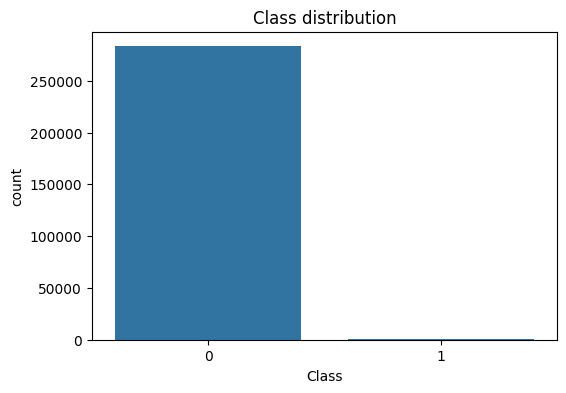

In [5]:
# 3) Basic EDA and data cleaning

df.drop_duplicates(inplace=True)

print('\nTarget distribution:\n', df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class distribution')
plt.show()



In [6]:
# 4) Preprocessing: split + scale
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train counts:\n', y_train.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: (226980, 30) Test: (56746, 30)
Train counts:
 Class
0    226602
1       378
Name: count, dtype: int64


In [7]:
# 5) Results container & helper to add results
results = []
def add_result(model_name, y_true, y_pred, y_scores=None):
    results.append({
        'Model': model_name,
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_scores) if y_scores is not None else float('nan')
    })


In [8]:
# 6) RandomForest experiments
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=dict(zip(classes,weights)))
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]
evaluate_model('RandomForest (class_weight)', y_test, y_pred_rf, y_prob_rf)
add_result('RandomForest (class_weight)', y_test, y_pred_rf, y_prob_rf)

# RF + SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
rf_sm = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sm.fit(X_res, y_res)
y_pred_rf_sm = rf_sm.predict(X_test_scaled)
y_prob_rf_sm = rf_sm.predict_proba(X_test_scaled)[:,1]
evaluate_model('RandomForest (SMOTE)', y_test, y_pred_rf_sm, y_prob_rf_sm)
add_result('RandomForest (SMOTE)', y_test, y_pred_rf_sm, y_prob_rf_sm)

# RF + SMOTEENN
smenn = SMOTEENN(random_state=42)
X_res2, y_res2 = smenn.fit_resample(X_train_scaled, y_train)
rf_smenn = RandomForestClassifier(n_estimators=200, random_state=42)
rf_smenn.fit(X_res2, y_res2)
y_pred_rf_smenn = rf_smenn.predict(X_test_scaled)
y_prob_rf_smenn = rf_smenn.predict_proba(X_test_scaled)[:,1]
evaluate_model('RandomForest (SMOTEENN)', y_test, y_pred_rf_smenn, y_prob_rf_smenn)
add_result('RandomForest (SMOTEENN)', y_test, y_pred_rf_smenn, y_prob_rf_smenn)


=== RandomForest (class_weight) ===
Confusion matrix:
 [[56649     2]
 [   28    67]]

Classification report:
               precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997     56651
           1     0.9710    0.7053    0.8171        95

    accuracy                         0.9995     56746
   macro avg     0.9853    0.8526    0.9084     56746
weighted avg     0.9995    0.9995    0.9994     56746

ROC-AUC: 0.9246080108215676


=== RandomForest (SMOTE) ===
Confusion matrix:
 [[56644     7]
 [   24    71]]

Classification report:
               precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9103    0.7474    0.8208        95

    accuracy                         0.9995     56746
   macro avg     0.9549    0.8736    0.9103     56746
weighted avg     0.9994    0.9995    0.9994     56746

ROC-AUC: 0.9730598893130515


=== RandomForest (SMOTEENN) ===
Confusion matrix:
 [[56639    12]
 [   

In [9]:
# 7) IsolationForest (unsupervised)
fraud_ratio = y_train.mean()
iso = IsolationForest(contamination=fraud_ratio, n_estimators=200, random_state=42)
iso.fit(X_train_scaled)
y_pred_iso = iso.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso==-1, 1, 0)
scores_iso = -iso.decision_function(X_test_scaled)
evaluate_model('IsolationForest', y_test, y_pred_iso, scores_iso)
add_result('IsolationForest', y_test, y_pred_iso, scores_iso)


=== IsolationForest ===
Confusion matrix:
 [[56580    71]
 [   77    18]]

Classification report:
               precision    recall  f1-score   support

           0     0.9986    0.9987    0.9987     56651
           1     0.2022    0.1895    0.1957        95

    accuracy                         0.9974     56746
   macro avg     0.6004    0.5941    0.5972     56746
weighted avg     0.9973    0.9974    0.9973     56746

ROC-AUC: 0.9304496877929409




In [10]:
# 8) XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                    scale_pos_weight=scale_pos_weight, use_label_encoder=False,
                    eval_metric='auc', random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]
evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
add_result('XGBoost', y_test, y_pred_xgb, y_prob_xgb)


=== XGBoost ===
Confusion matrix:
 [[56646     5]
 [   22    73]]

Classification report:
               precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56651
           1     0.9359    0.7684    0.8439        95

    accuracy                         0.9995     56746
   macro avg     0.9678    0.8842    0.9218     56746
weighted avg     0.9995    0.9995    0.9995     56746

ROC-AUC: 0.9744916473811491




In [12]:
# 9) Autoencoder (semi-supervised)
import torch, torch.nn as nn, torch.optim as optim
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

X_train_normal = X_train_t[y_train_np == 0]
input_dim = X_train_scaled.shape[1]

class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoEncoder(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train (use smaller batch if data is large)
Xn = X_train_normal.to(device)
epochs = 30
for epoch in range(1, epochs+1):
    model.train()
    optimizer.zero_grad()
    out = model(Xn)
    loss = criterion(out, Xn)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0 or epoch==1:
        print(f'Epoch {epoch}/{epochs} - Loss: {loss.item():.6f}')

# Train reconstruction errors
model.eval()
with torch.no_grad():
    recon_train = model(Xn).cpu().numpy()
    train_err = np.mean((X_train_normal.numpy() - recon_train)**2, axis=1)

threshold = np.percentile(train_err, 95)
print('AE threshold (95th percentile):', threshold)

# Test reconstruction errors
with torch.no_grad():
    recon_test = model(X_test_t.to(device)).cpu().numpy()
    test_err = np.mean((X_test_t.numpy() - recon_test)**2, axis=1)

y_pred_ae = (test_err > threshold).astype(int)
evaluate_model('Autoencoder (PyTorch)', y_test_np, y_pred_ae, test_err)
add_result('Autoencoder (PyTorch)', y_test_np, y_pred_ae, test_err)


Epoch 1/30 - Loss: 0.980544
Epoch 5/30 - Loss: 0.976865
Epoch 10/30 - Loss: 0.973143
Epoch 15/30 - Loss: 0.970074
Epoch 20/30 - Loss: 0.967339
Epoch 25/30 - Loss: 0.964560
Epoch 30/30 - Loss: 0.961340
AE threshold (95th percentile): 1.9097608
=== Autoencoder (PyTorch) ===
Confusion matrix:
 [[53814  2837]
 [   17    78]]

Classification report:
               precision    recall  f1-score   support

           0     0.9997    0.9499    0.9742     56651
           1     0.0268    0.8211    0.0518        95

    accuracy                         0.9497     56746
   macro avg     0.5132    0.8855    0.5130     56746
weighted avg     0.9981    0.9497    0.9726     56746

ROC-AUC: 0.9377925228244217




In [13]:
# 10) Hybrid (XGB prob + normalized AE error)
err_norm = (test_err - test_err.min()) / (test_err.max() - test_err.min() + 1e-9)
final_score = 0.6 * y_prob_xgb + 0.4 * err_norm

from sklearn.metrics import f1_score
best_f1 = 0; best_thr = 0.5
for thr in np.linspace(0.1, 0.9, 81):
    yph = (final_score > thr).astype(int)
    f = f1_score(y_test, yph)
    if f > best_f1:
        best_f1 = f; best_thr = thr
print('Best threshold on grid:', best_thr, 'F1:', best_f1)

y_pred_hybrid = (final_score > best_thr).astype(int)
evaluate_model('Hybrid (XGB + AE)', y_test, y_pred_hybrid, final_score)
add_result('Hybrid (XGB + AE)', y_test, y_pred_hybrid, final_score)


Best threshold on grid: 0.49 F1: 0.8588235294117647
=== Hybrid (XGB + AE) ===
Confusion matrix:
 [[56649     2]
 [   22    73]]

Classification report:
               precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     56651
           1     0.9733    0.7684    0.8588        95

    accuracy                         0.9996     56746
   macro avg     0.9865    0.8842    0.9293     56746
weighted avg     0.9996    0.9996    0.9996     56746

ROC-AUC: 0.9585158992873262




SHAP summary (may be slow):


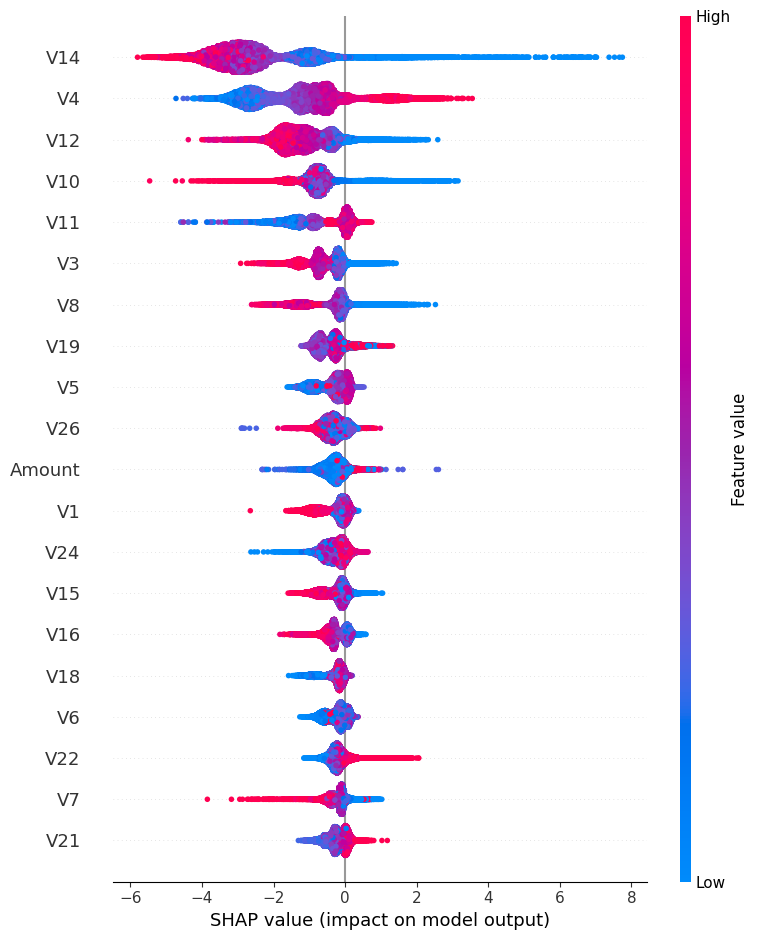

In [14]:
# 11) SHAP (optional)
try:
    import shap
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_test_scaled)
    print('SHAP summary (may be slow):')
    shap.summary_plot(shap_values, X_test)
except Exception as e:
    print('SHAP failed or not installed:', e)
    print('Install shap with: pip install shap')


,Model,Precision,Recall,F1,ROC-AUC
0,Hybrid (XGB + AE),0.973333,0.768421,0.858824,0.958516
1,XGBoost,0.935897,0.768421,0.843931,0.974492
2,RandomForest (SMOTE),0.910256,0.747368,0.820809,0.973060
3,RandomForest (SMOTEENN),0.860465,0.778947,0.817680,0.962017
4,RandomForest (class_weight),0.971014,0.705263,0.817073,0.924608
5,IsolationForest,0.202247,0.189474,0.195652,0.930450
6,Autoencoder (PyTorch),0.026758,0.821053,0.051827,0.937793
7,Autoencoder (PyTorch),0.026749,0.821053,0.051810,0.937840


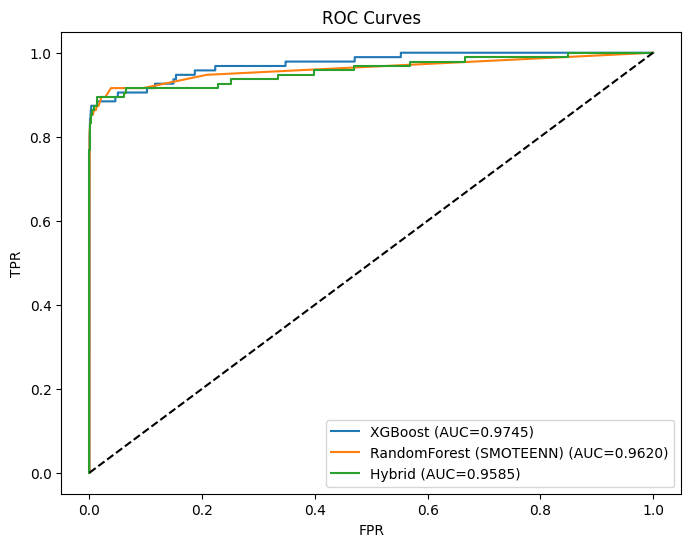

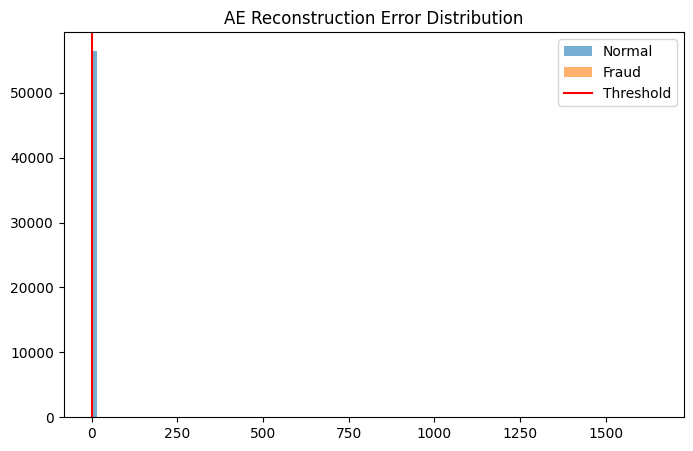

In [15]:
# 12) Results table and visualizations
import pandas as pd
res_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
display(res_df)

# ROC curves for selected models
from sklearn.metrics import roc_curve
plt.figure(figsize=(8,6))
for name, scores in [('XGBoost', y_prob_xgb), ('RandomForest (SMOTEENN)', y_prob_rf_smenn), ('Hybrid', final_score)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.4f})')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(); plt.show()

# AE reconstruction histogram
plt.figure(figsize=(8,5))
plt.hist(test_err[y_test==0], bins=100, alpha=0.6, label='Normal')
plt.hist(test_err[y_test==1], bins=100, alpha=0.6, label='Fraud')
plt.axvline(threshold, color='red', label='Threshold')
plt.legend(); plt.title('AE Reconstruction Error Distribution'); plt.show()
